**Install & Imports**

In [ ]:
!pip install --quiet yfinance pandas numpy scikit-learn tensorflow joblib matplotlib

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import os, math, joblib
from datetime import date
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

**Global Configurations**

In [ ]:
SEQ_LEN = 60
EPOCHS = 50
BATCH_SIZE = 64
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

**Utilities (Functions + Preprocessing)**

In [ ]:
def fetch_data(ticker, period = "5y") :
    df = yf.download(ticker, period=period, progress=False)
    df = df[["Close"]].dropna()
    return df

In [ ]:
def split_data(df, train=0.7, val=0.15):
    n = len(df)
    train_end = int(train * n)
    val_end = int((train + val) * n)
    return df[:train_end], df[train_end:val_end], df[val_end:]

In [ ]:
def create_sequences(data, seq_len, target_index=0):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])           # sequence of features
        y.append(data[i, target_index])       # target value
    return np.array(X), np.array(y)

**Metrics**

In [ ]:
def direction_acc(y_true, y_pred):
    return np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred)))

In [ ]:
def evaluate(name, y_true, y_pred):
    return {
        f"{name}_MAE": mean_absolute_error(y_true, y_pred),
        f"{name}_RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        f"{name}_R2": r2_score(y_true, y_pred),
        f"{name}_DirAcc": direction_acc(y_true, y_pred)
    }

**LSTM Model Definition**

In [ ]:
def build_lstm(seq_len, n_features, bidirectional=True):
    model = Sequential()
    model.add(Input(shape=(seq_len, n_features)))
    if bidirectional:
        model.add(Bidirectional(LSTM(128, return_sequences=True)))
        model.add(Dropout(0.3))
        model.add(Bidirectional(LSTM(64)))
    else:
        model.add(LSTM(128, return_sequences=True))
        model.add(Dropout(0.3))
        model.add(LSTM(64))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mae', metrics=['mae'])
    return model

**Training Pipeline (LSTM + RF Residual)**

In [ ]:
def train_pipeline(ticker):
    print(f"\n================ TRAINING {ticker} =================\n")

    # Fetch + indicators
    df = fetch_data(ticker, period = "5y")
    if isinstance(df.columns, pd.MultiIndex):
      df.columns = [c[0] for c in df.columns]
    feature_cols = df.columns.tolist()
    df_train, df_val, df_test = split_data(df)
    print("\nFetch & Indicators completed successfully!")

    # Scaling
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(df_train)
    val_scaled   = scaler.transform(df_val)
    test_scaled  = scaler.transform(df_test)
    print("\nScaling completed successfully!")

    # Sequences
    X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
    X_val, y_val = create_sequences(val_scaled, SEQ_LEN)
    X_test, y_test = create_sequences(test_scaled, SEQ_LEN)
    n_features = X_train.shape[2]
    print("\nSequences creation completed successfully!")

    # LSTM Training & Prediction
    print("\nLSTM Training:")
    lstm = build_lstm(SEQ_LEN, n_features)

    history = lstm.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        shuffle=False,
        verbose=1
    )
    print("\nLSTM Training completed successfully!")

    lstm_val_pred  = lstm.predict(X_val).flatten()
    lstm_test_pred = lstm.predict(X_test).flatten()
    print("\nLSTM Evaluation completed successfully!")

    # RF Residuals Training & Prediction
    print("\nRandom Forest Training:")
    residuals_train = y_train.flatten() - lstm.predict(X_train).flatten()

    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        random_state=SEED,
        n_jobs=-1
    )

    rf.fit(X_train.reshape(len(X_train), -1), residuals_train)
    print("\nRandom Forest Training completed successfully!")

    rf_val_resid  = rf.predict(X_val.reshape(len(X_val), -1))
    rf_test_resid = rf.predict(X_test.reshape(len(X_test), -1))
    print("\nRandom Forest Evaluation completed successfully!")

    # Hybrid Prediction
    hybrid_val_pred  = lstm_val_pred  + rf_val_resid
    hybrid_test_pred = lstm_test_pred + rf_test_resid

    # Inverse Scaling
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1,1)).flatten()
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    lstm_val_inv = scaler.inverse_transform(lstm_val_pred.reshape(-1,1)).flatten()
    lstm_test_inv = scaler.inverse_transform(lstm_test_pred.reshape(-1,1)).flatten()

    hybrid_val_inv = scaler.inverse_transform(hybrid_val_pred.reshape(-1,1)).flatten()
    hybrid_test_inv = scaler.inverse_transform(hybrid_test_pred.reshape(-1,1)).flatten()

    # ===================== Metrices =====================
    results = {}
    results.update(evaluate("LSTM_Val", y_val_inv, lstm_val_inv))
    results.update(evaluate("LSTM_Test", y_test_inv, lstm_test_inv))
    results.update(evaluate("Hybrid_Val", y_val_inv, hybrid_val_inv))
    results.update(evaluate("Hybrid_Test", y_test_inv, hybrid_test_inv))

    results["y_test"] = y_test_inv
    results["lstm_pred"] = lstm_test_inv
    results["hybrid_pred"] = hybrid_test_inv
    results["hybrid_weighted"] = hybrid_test_inv
    results["history"] = history

    # Save Models & Meta
    os.makedirs(f'Models/{ticker}', exist_ok=True)
    lstm.save(f'Models/{ticker}/lstm_model.keras')
    joblib.dump(rf, f'Models/{ticker}/rf_model.joblib')
    joblib.dump(scaler, f'Models/{ticker}/feature_scaler.joblib')

    meta = {
        'Ticker': ticker,
        'feature_cols': feature_cols,
        'seq_len': SEQ_LEN,
        'n_features': n_features,
        'results': results  # optional: save metrics as well
    }

    joblib.dump(meta, f'Models/{ticker}/meta.joblib')
    print(f"\nAll Models, Metrics, and Meta for {ticker} saved successfully!")

    return results

**Visualization**

In [ ]:
# Price Prediction
def visualize_predictions(ticker, y_test, lstm_pred, hybrid_pred):
    plt.figure(figsize=(16,5))
    plt.plot(y_test, label="Real Price", linewidth=2, color='black')
    plt.plot(lstm_pred, label="LSTM Prediction", alpha=0.7, linestyle='--', color='blue')
    plt.plot(hybrid_pred, label="Hybrid Prediction", linewidth=2, linestyle='-', color='red')

    plt.title(f"{ticker} — Test Set: Real vs Predicted Prices (5 Years)")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Caption
    plt.figtext(0.5, -0.05,
                "(a) Real Price\n(b) LSTM Prediction\n(c) Hybrid Prediction",
                ha='center', fontsize=10)
    plt.show()


In [ ]:
# Training vs Validation Loss
def visualize_loss(ticker, history):
    plt.figure(figsize=(8,4))

    # Plot lines
    plt.plot(history.history["loss"], label="Train MAE", color='blue', linewidth=2)
    plt.plot(history.history["val_loss"], label="Validation MAE", color='orange', linewidth=2)

    # Highlight min validation loss
    min_val_epoch = np.argmin(history.history["val_loss"])
    min_val_loss  = history.history["val_loss"][min_val_epoch]
    plt.scatter(min_val_epoch, min_val_loss, color='red', zorder=5)
    plt.text(min_val_epoch, min_val_loss, f"{min_val_loss:.3f}", color='red', fontsize=9, va='bottom')

    # Titles and labels
    plt.title(f"{ticker} — LSTM Training Loss vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MAE")

    # Grid & legend
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()

    # Layout & caption
    plt.tight_layout()
    plt.figtext(0.5, -0.05,
                "Insight: Convergence of training and validation loss indicates good fit; "
                "early stopping prevents overfitting.",
                wrap=True, ha='center', fontsize=10)

    plt.show()


**Running**


================ TRAINING TSLA =================



/tmp/ipython-input-1732409603.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)



Fetch & Indicators completed successfully!

Scaling completed successfully!

Sequences creation completed successfully!

LSTM Training:
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - loss: 0.2373 - mae: 0.2373 - val_loss: 0.2241 - val_mae: 0.2241
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0922 - mae: 0.0922 - val_loss: 0.2206 - val_mae: 0.2206
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.1017 - mae: 0.1017 - val_loss: 0.2145 - val_mae: 0.2145
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.1220 - mae: 0.1220 - val_loss: 0.1044 - val_mae: 0.1044
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0748 - mae: 0.0748 - val_loss: 0.0868 - val_mae: 0.0868
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0589 - mae: 0.0589 - val_loss: 0.0711 - val_mae: 0.0711
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0513 - mae: 0.0513 - val_loss: 0.0742 - val_mae: 0.0742
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22

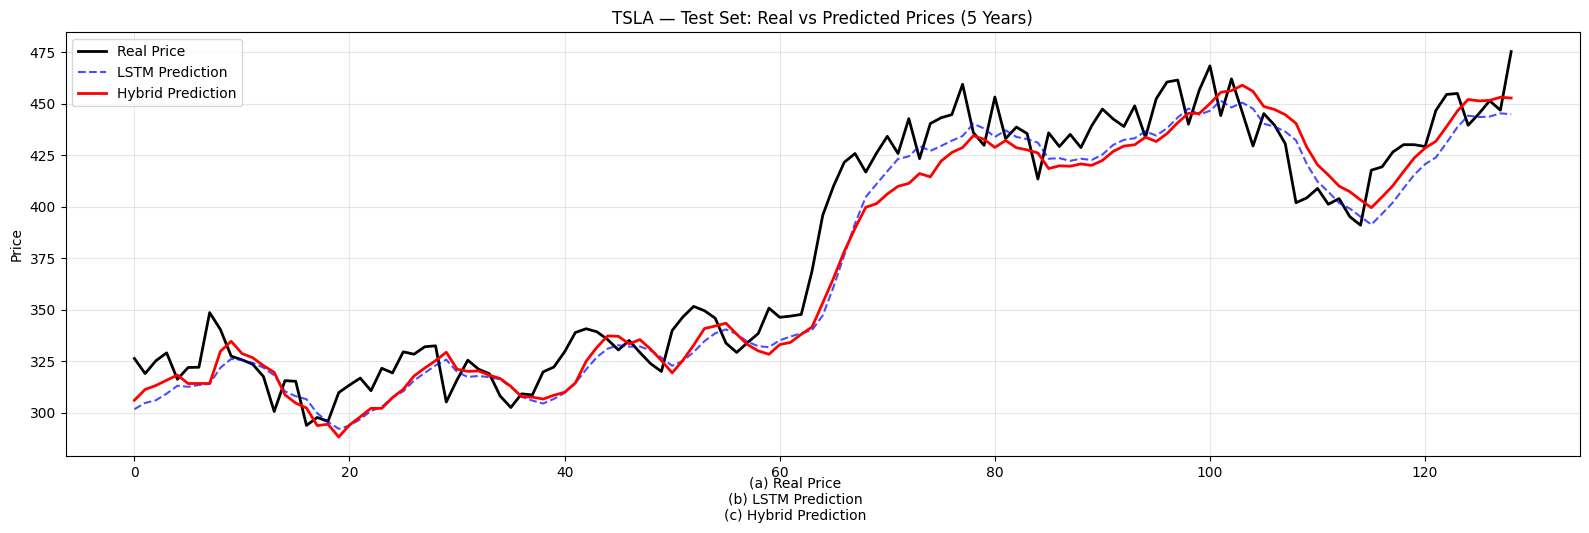

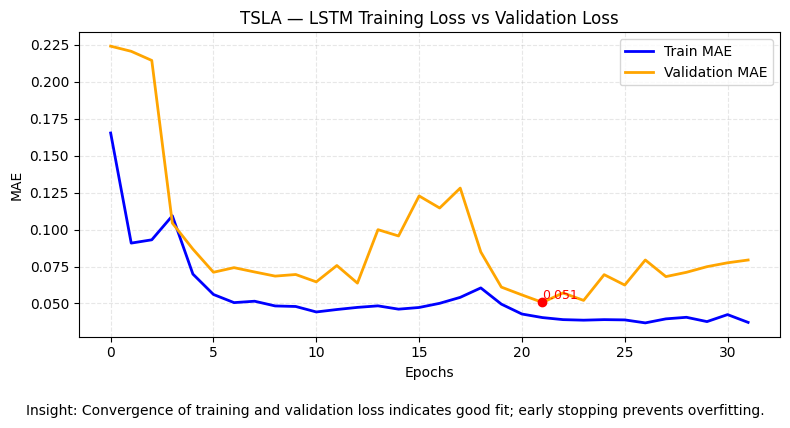


================ TRAINING AMD =================


Fetch & Indicators completed successfully!

Scaling completed successfully!

Sequences creation completed successfully!

LSTM Training:


/tmp/ipython-input-1732409603.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.1668 - mae: 0.1668 - val_loss: 0.0747 - val_mae: 0.0747
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0754 - mae: 0.0754 - val_loss: 0.0493 - val_mae: 0.0493
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0569 - mae: 0.0569 - val_loss: 0.0491 - val_mae: 0.0491
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0461 - mae: 0.0461 - val_loss: 0.0413 - val_mae: 0.0413
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0414 - mae: 0.0414 - val_loss: 0.0366 - val_mae: 0.0366
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0476 - mae: 0.0476 - val_loss: 0.0376 - val_mae: 0.0376
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0436 - mae: 0.0436 - val_loss: 0.0314 - val_mae: 0.0314
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0362 - mae: 0.0362 - val_loss: 0.0294 - val_mae: 0.0294
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.035

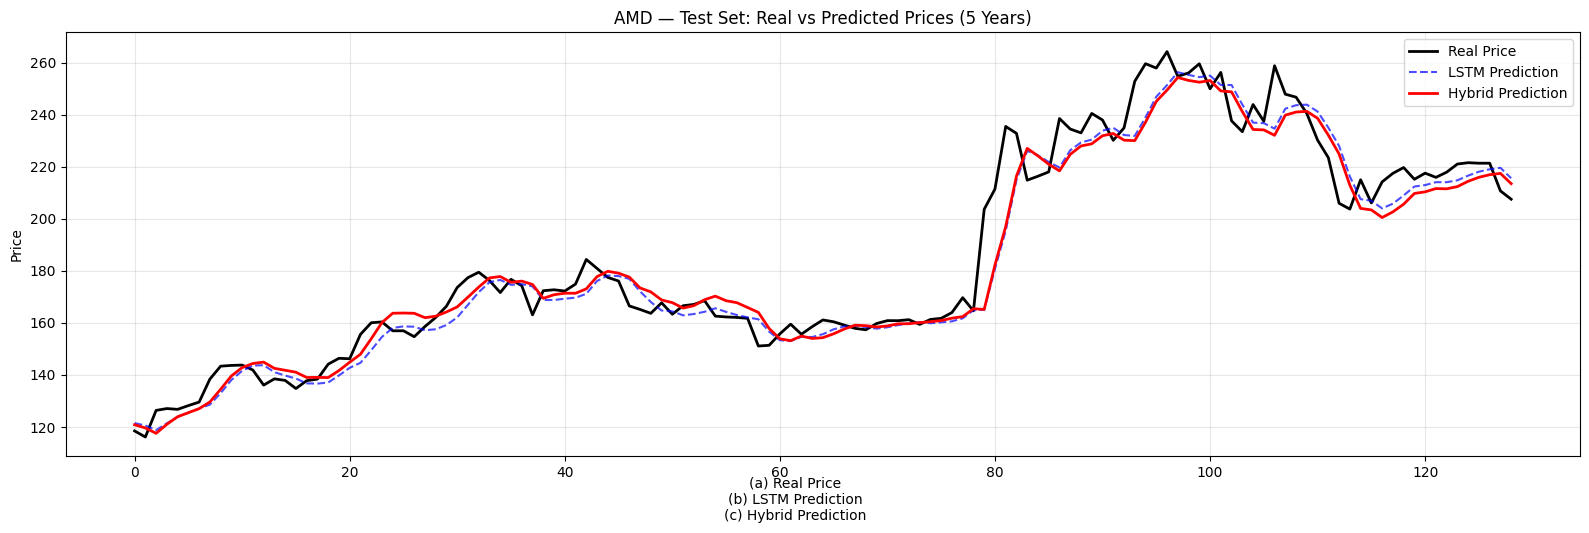

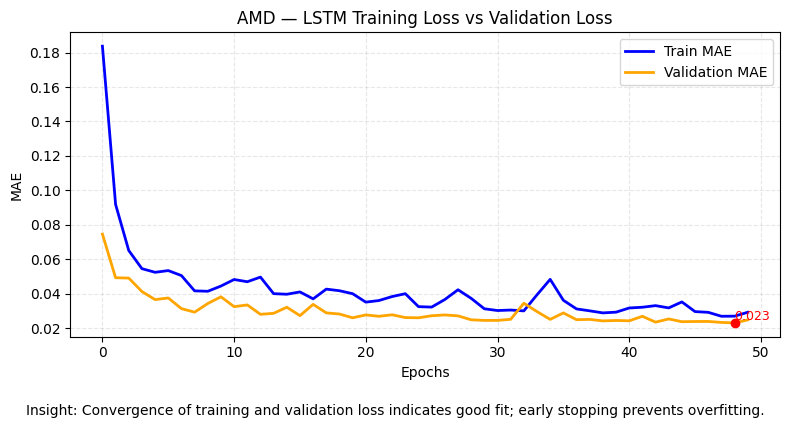


================ TRAINING SNPS =================


Fetch & Indicators completed successfully!

Scaling completed successfully!

Sequences creation completed successfully!

LSTM Training:


/tmp/ipython-input-1732409603.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.1069 - mae: 0.1069 - val_loss: 0.2264 - val_mae: 0.2264
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1237 - mae: 0.1237 - val_loss: 0.0700 - val_mae: 0.0700
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0772 - mae: 0.0772 - val_loss: 0.0512 - val_mae: 0.0512
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0828 - mae: 0.0828 - val_loss: 0.0492 - val_mae: 0.0492
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0655 - mae: 0.0655 - val_loss: 0.1229 - val_mae: 0.1229
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0983 - mae: 0.0983 - val_loss: 0.0525 - val_mae: 0.0525
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0742 - mae: 0.0742 - val_loss: 0.0507 - val_mae: 0.0507
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0554 - mae: 0.0554 - val_loss: 0.1359 - val_mae: 0.1359
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.101

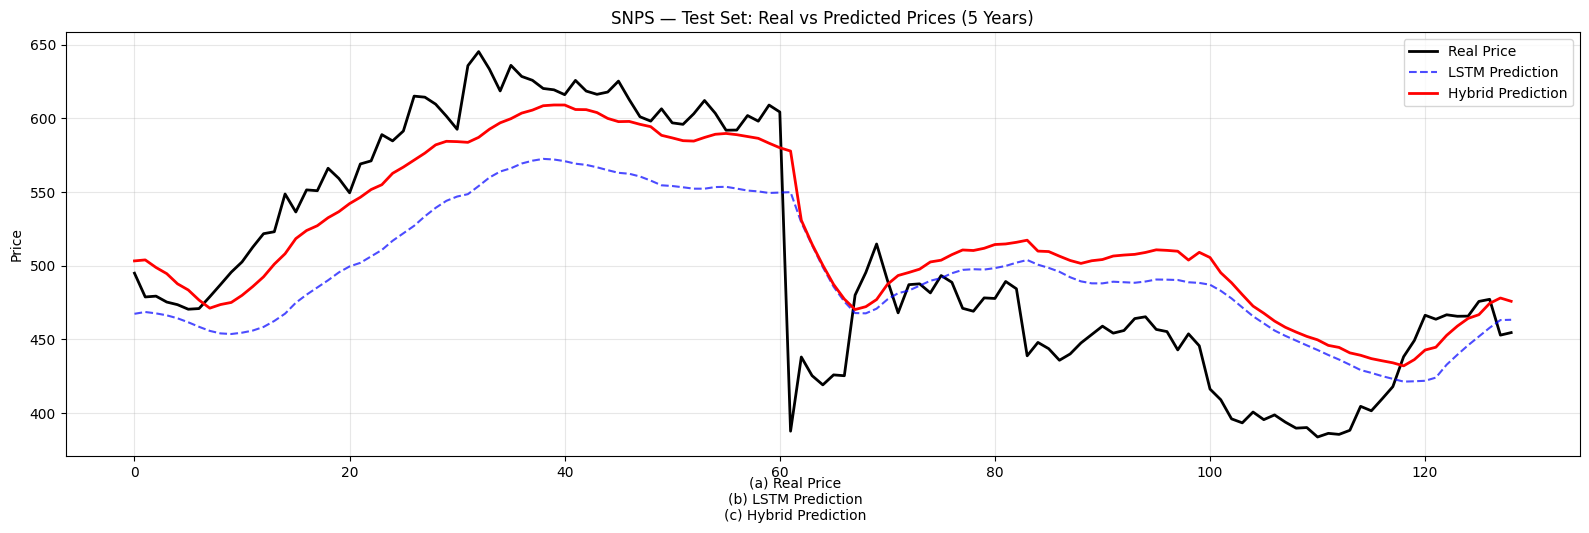

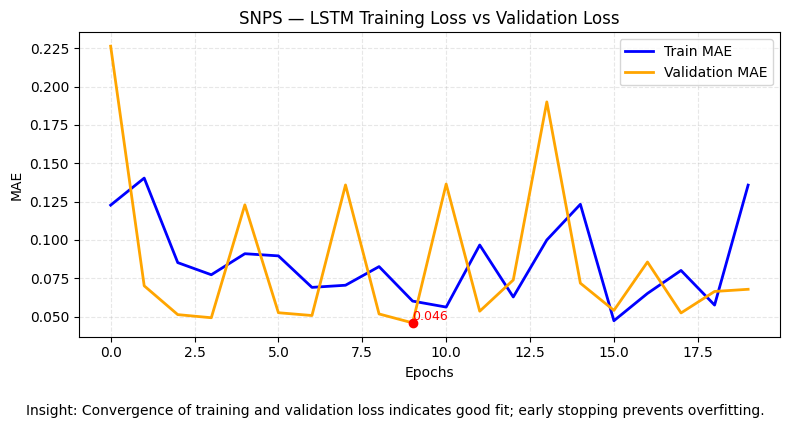


================ TRAINING GOOG =================


Fetch & Indicators completed successfully!

Scaling completed successfully!

Sequences creation completed successfully!

LSTM Training:


/tmp/ipython-input-1732409603.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.2352 - mae: 0.2352 - val_loss: 0.3045 - val_mae: 0.3045
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1155 - mae: 0.1155 - val_loss: 0.2032 - val_mae: 0.2032
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0813 - mae: 0.0813 - val_loss: 0.1075 - val_mae: 0.1075
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0682 - mae: 0.0682 - val_loss: 0.0695 - val_mae: 0.0695
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0712 - mae: 0.0712 - val_loss: 0.0702 - val_mae: 0.0702
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0670 - mae: 0.0670 - val_loss: 0.0893 - val_mae: 0.0893
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0607 - mae: 0.0607 - val_loss: 0.0637 - val_mae: 0.0637
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0563 - mae: 0.0563 - val_loss: 0.0503 - val_mae: 0.0503
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.053

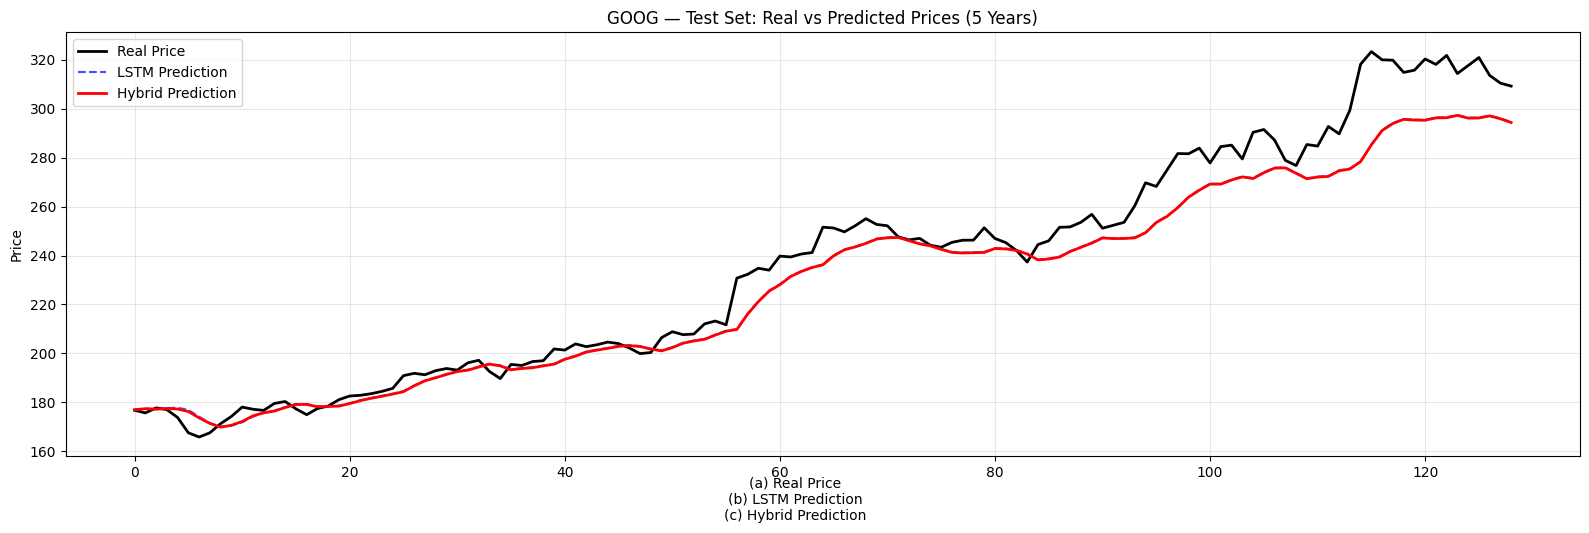

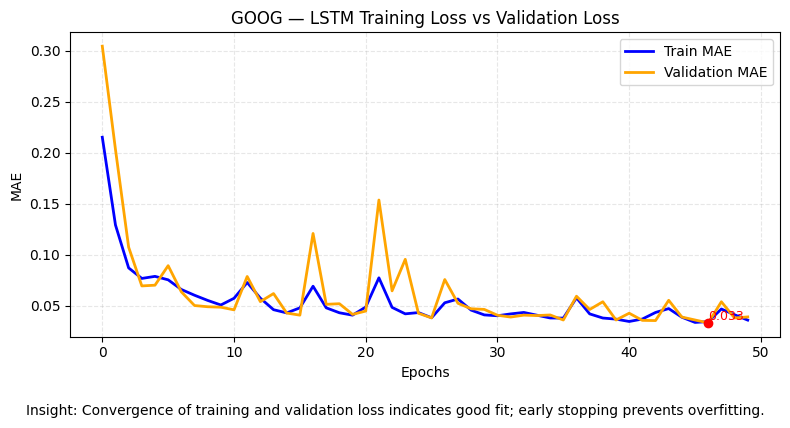


================ TRAINING ADBE =================


Fetch & Indicators completed successfully!

Scaling completed successfully!

Sequences creation completed successfully!

LSTM Training:


/tmp/ipython-input-1732409603.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.3452 - mae: 0.3452 - val_loss: 0.1213 - val_mae: 0.1213
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0982 - mae: 0.0982 - val_loss: 0.0759 - val_mae: 0.0759
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1377 - mae: 0.1377 - val_loss: 0.0459 - val_mae: 0.0459
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0916 - mae: 0.0916 - val_loss: 0.0377 - val_mae: 0.0377
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0757 - mae: 0.0757 - val_loss: 0.0473 - val_mae: 0.0473
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0623 - mae: 0.0623 - val_loss: 0.0522 - val_mae: 0.0522
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0663 - mae: 0.0663 - val_loss: 0.0388 - val_mae: 0.0388
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0829 - mae: 0.0829 - val_loss: 0.0415 - val_mae: 0.0415
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.074

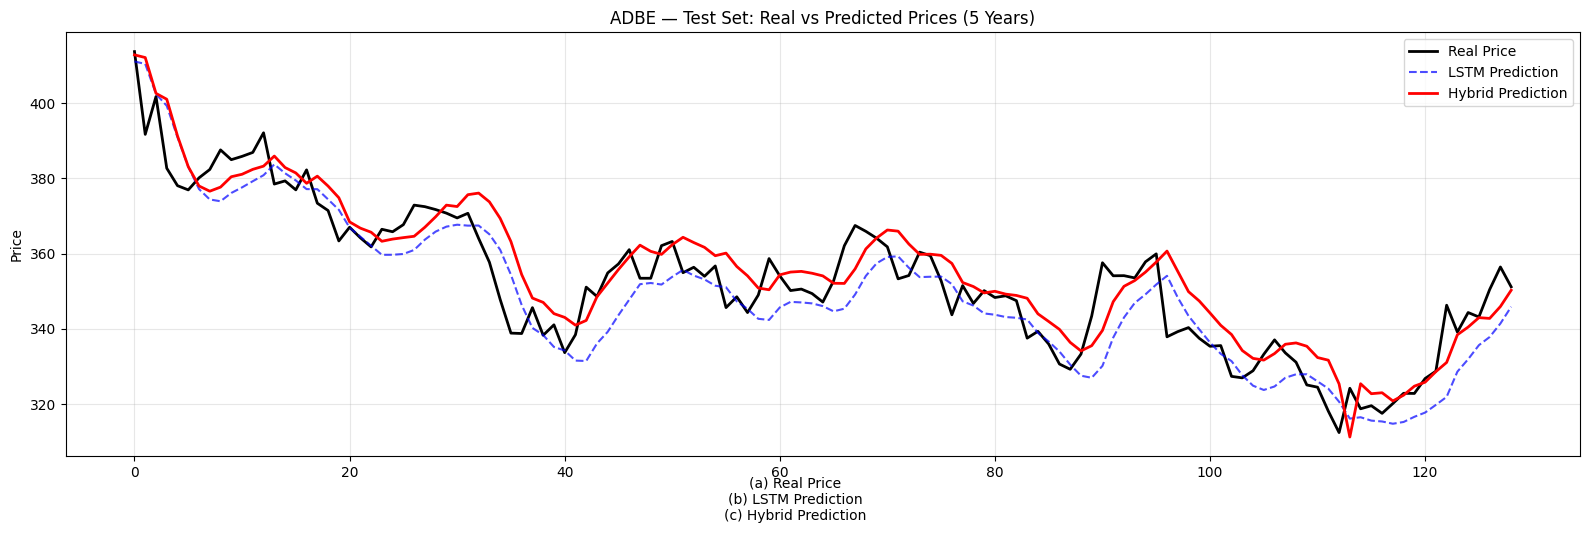

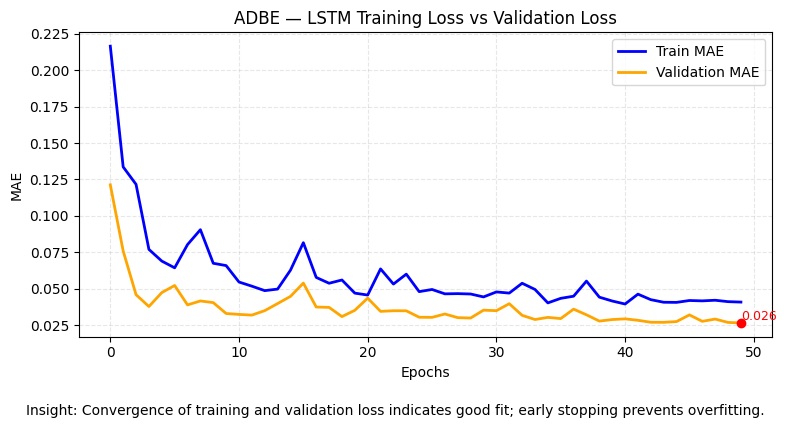


================ TRAINING TXN =================



/tmp/ipython-input-1732409603.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)



Fetch & Indicators completed successfully!

Scaling completed successfully!

Sequences creation completed successfully!

LSTM Training:
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.2759 - mae: 0.2759 - val_loss: 0.0882 - val_mae: 0.0882
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1126 - mae: 0.1126 - val_loss: 0.1551 - val_mae: 0.1551
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1021 - mae: 0.1021 - val_loss: 0.2594 - val_mae: 0.2594
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0993 - mae: 0.0993 - val_loss: 0.2309 - val_mae: 0.2309
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0938 - mae: 0.0938 - val_loss: 0.1767 - val_mae: 0.1767
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0780 - mae: 0.0780 - val_loss: 0.1164 - val_mae: 0.1164
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0700 - mae: 0.0700 - val_loss: 0.0950 - val_mae: 0.0950
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26m

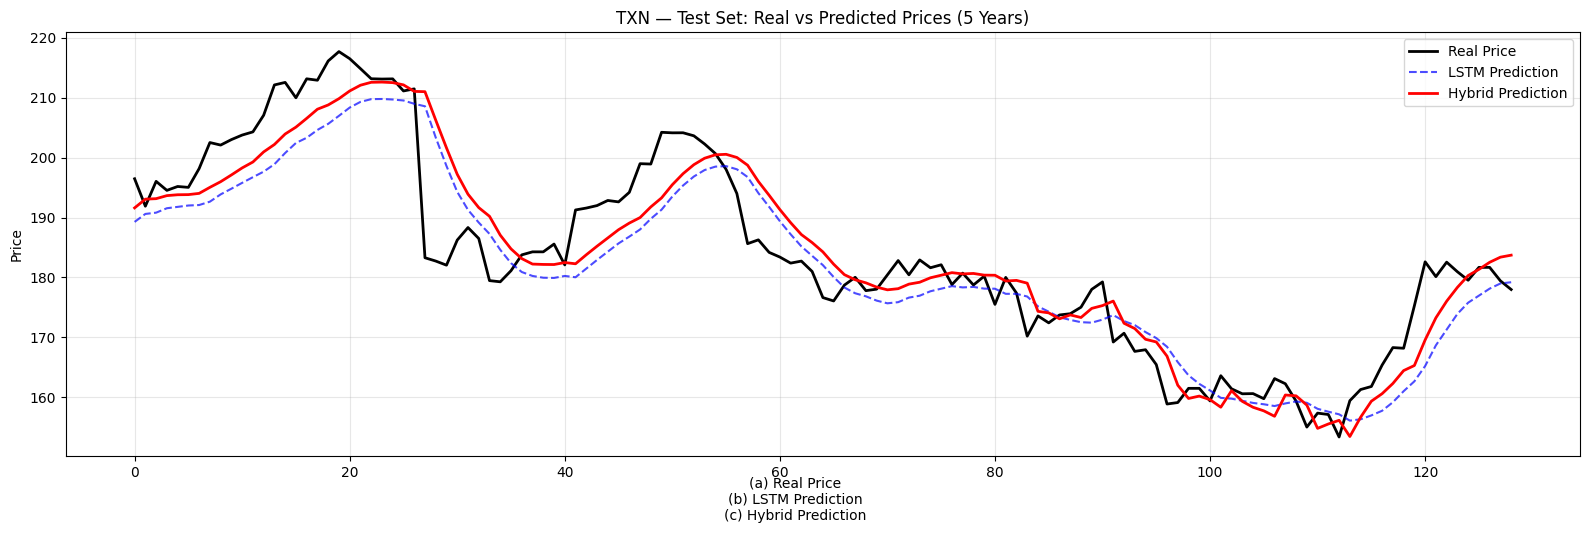

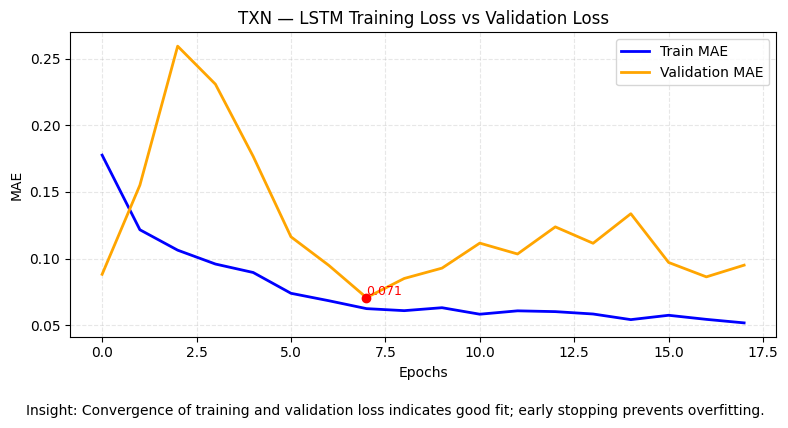

,LSTM_Val_MAE,LSTM_Val_RMSE,LSTM_Val_R2,LSTM_Val_DirAcc,LSTM_Test_MAE,LSTM_Test_RMSE,LSTM_Test_R2,LSTM_Test_DirAcc,RF_Val_MAE,RF_Val_RMSE,...,Hybrid_Test_RMSE,Hybrid_Test_R2,Hybrid_Test_DirAcc,y_test,lstm_pred,rf_resid,hybrid_pred,hybrid_weighted,history,Ticker
0,15.298913,20.501113,0.925161,0.527559,12.900509,16.115115,0.918886,0.507812,209.790567,223.504356,...,16.509769,0.914865,0.500000,"[326.42999267578125, 319.1099853515625, 325.30...","[301.80832, 304.8324, 306.146, 309.3444, 313.1...","[112.43352895379196, 114.64661738481186, 115.2...","[306.141845247704, 311.3790106907634, 313.3084...","[306.141845247704, 311.3790106907634, 313.3084...",<keras.src.callbacks.history.History object at...,TSLA
1,3.596337,4.565735,0.952076,0.456693,6.451452,9.307301,0.944258,0.500000,77.163646,79.727238,...,9.462913,0.942379,0.500000,"[118.5, 116.16000366210938, 126.38999938964842...","[121.515114, 120.568695, 118.80261, 121.437, 1...","[55.3094599719659, 54.99910151665065, 54.71896...","[120.88457765533086, 119.6278002971974, 117.58...","[120.88457765533086, 119.6278002971974, 117.58...",<keras.src.callbacks.history.History object at...,AMD
2,17.581277,22.834259,0.502494,0.503937,45.723956,52.013478,0.563679,0.460938,271.968486,273.381248,...,43.668774,0.692450,0.523438,"[494.989990234375, 478.8599853515625, 479.4100...","[467.42706, 468.65213, 467.71603, 466.39548, 4...","[254.38415258392328, 253.8374899760743, 249.63...","[503.3212289025695, 503.99961084495817, 498.86...","[503.3212289025695, 503.99961084495817, 498.86...",<keras.src.callbacks.history.History object at...,SNPS
3,3.178333,4.215709,0.899672,0.472441,8.469208,11.698816,0.936923,0.546875,95.216110,96.164043,...,11.798480,0.935844,0.554688,"[176.69668579101562, 175.60838317871094, 177.6...","[177.0754, 177.38484, 177.15486, 177.59836, 17...","[82.67301975294116, 82.81306710473199, 82.8318...","[176.87994272540502, 177.3294306567395, 177.11...","[176.87994272540502, 177.3294306567395, 177.11...",<keras.src.callbacks.history.History object at...,GOOG
4,10.938811,15.821760,0.852174,0.519685,6.907156,8.739049,0.792966,0.476562,196.900476,201.075964,...,8.198591,0.817781,0.492188,"[413.6799926757812, 391.67999267578125, 401.73...","[411.05945, 410.40253, 402.42767, 399.27072, 3...","[276.9555644891886, 276.8951238238313, 275.344...","[412.815013083348, 412.0976265657044, 402.5720...","[412.815013083348, 412.0976265657044, 402.5720...",<keras.src.callbacks.history.History object at...,ADBE
5,4.335887,5.838012,0.560220,0.456693,5.527522,6.974247,0.817727,0.484375,55.307466,55.986789,...,6.315595,0.850529,0.476562,"[196.4735565185547, 191.88792419433594, 196.04...","[189.26674, 190.59763, 190.81142, 191.54921, 1...","[134.65379883361504, 134.78253025946566, 134.6...","[191.6084287729228, 193.0680417804861, 193.148...","[191.6084287729228, 193.0680417804861, 193.148...",<keras.src.callbacks.history.History object at...,TXN


In [ ]:
tickers = ["TSLA", "AMD", "SNPS", "GOOG", "ADBE", "TXN"]

all_results = []

for t in tickers:
    res = train_pipeline(t)

    visualize_predictions(
        t,
        res["y_test"],
        res["lstm_pred"],
        res["hybrid_pred"]
    )

    visualize_loss(
        t,
        res["history"]
    )

    res["Ticker"] = t
    all_results.append(res)

summary = pd.DataFrame(all_results)

summary

In [ ]:
summary['Hybrid_Val_R2']

,Hybrid_Val_R2
0,0.920697
1,0.953070
2,0.471385
3,0.900790
4,0.857017
5,0.644994


**Zip & Download Saved Models**

In [ ]:
import shutil

shutil.make_archive('Models', 'zip', 'Models')

from google.colab import files
files.download('Models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

shutil.make_archive('Models', 'zip', 'Models')

from google.colab import files
files.download('Models.zip')

In [ ]:
!unzip Models.zip -d Models

Archive:  Models.zip
   creating: Models/Models/
  inflating: Models/__MACOSX/._Models  
   creating: Models/Models/SNPS/
  inflating: Models/__MACOSX/Models/._SNPS  
   creating: Models/Models/GOOG/
  inflating: Models/__MACOSX/Models/._GOOG  
  inflating: Models/Models/.DS_Store  
  inflating: Models/__MACOSX/Models/._.DS_Store  
   creating: Models/Models/TXN/
  inflating: Models/__MACOSX/Models/._TXN  
   creating: Models/Models/TSLA/
  inflating: Models/__MACOSX/Models/._TSLA  
   creating: Models/Models/AMD/
  inflating: Models/__MACOSX/Models/._AMD  
   creating: Models/Models/ADBE/
  inflating: Models/__MACOSX/Models/._ADBE  
  inflating: Models/Models/SNPS/lstm_model.keras  
  inflating: Models/__MACOSX/Models/SNPS/._lstm_model.keras  
  inflating: Models/Models/SNPS/meta.joblib  
  inflating: Models/__MACOSX/Models/SNPS/._meta.joblib  
  inflating: Models/Models/SNPS/rf_model.joblib  
  inflating: Models/__MACOSX/Models/SNPS/._rf_model.joblib  
  inflating: Models/Models/SNPS

In [ ]:
def load_ticker_summary(models_dir="Models"):
    summary_rows = []

    tickers = sorted(os.listdir(models_dir))

    for ticker in tickers:
        ticker_path = os.path.join(models_dir, ticker)
        if not os.path.isdir(ticker_path):
            continue

        meta_path = os.path.join(ticker_path, "meta.joblib")
        if not os.path.exists(meta_path):
            print(f"⚠️ Missing meta for {ticker}")
            continue

        meta = joblib.load(meta_path)
        results = meta["results"]

        row = {
            "Ticker": ticker,

            # LSTM
            "LSTM_Val_R2": results.get("LSTM_Val_R2"),
            "LSTM_Test_R2": results.get("LSTM_Test_R2"),
            "LSTM_Test_MAE": results.get("LSTM_Test_MAE"),
            "LSTM_Test_RMSE": results.get("LSTM_Test_RMSE"),
            "LSTM_Test_DirAcc": results.get("LSTM_Test_DirAcc"),

            # Hybrid
            "Hybrid_Val_R2": results.get("Hybrid_Val_R2"),
            "Hybrid_Test_R2": results.get("Hybrid_Test_R2"),
            "Hybrid_Test_MAE": results.get("Hybrid_Test_MAE"),
            "Hybrid_Test_RMSE": results.get("Hybrid_Test_RMSE"),
            "Hybrid_Test_DirAcc": results.get("Hybrid_Test_DirAcc"),
        }

        summary_rows.append(row)

    return pd.DataFrame(summary_rows)


In [ ]:
summary = load_ticker_summary("Models/Models")
summary


,Ticker,LSTM_Val_R2,LSTM_Test_R2,LSTM_Test_MAE,LSTM_Test_RMSE,LSTM_Test_DirAcc,Hybrid_Val_R2,Hybrid_Test_R2,Hybrid_Test_MAE,Hybrid_Test_RMSE,Hybrid_Test_DirAcc
0,ADBE,0.852174,0.792966,6.907156,8.739049,0.476562,0.857017,0.817781,6.308428,8.198591,0.492188
1,AMD,0.952076,0.944258,6.451452,9.307301,0.500000,0.953070,0.942379,6.711031,9.462913,0.500000
2,GOOG,0.899672,0.936923,8.469208,11.698816,0.546875,0.900790,0.935844,8.569512,11.798480,0.554688
3,SNPS,0.502494,0.563679,45.723956,52.013478,0.460938,0.471385,0.692450,34.194203,43.668774,0.523438
4,TSLA,0.925161,0.918886,12.900509,16.115115,0.507812,0.920697,0.914865,13.495955,16.509769,0.500000
5,TXN,0.560220,0.817727,5.527522,6.974247,0.484375,0.644994,0.850529,4.646718,6.315595,0.476562
